### 02成本函数 Cost Function (策略) 7-9

#### 1. 核心概念
通常用J(w,b)：表示当前这组 $w$ 和 $b$ 对应的预测误差有多大。越小越好

---

#### 2. 预测值和真实值
对于一个训练样本：
- 真实值：$y$
- 预测值：$\hat{y}$
- 预测公式：$\hat{y} = wx + b$
  
误差：$\hat{y}$ - y  (预测值 - 真实值)

---

### 3. 成本函数公式
线性回归常用的成本函数是：

$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}^{(i)} - y^{(i)})^2 $

也可以写成：

$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $

#### 3.1. 公式里的符号是什么意思？

- $J(w,b)$：成本函数
- $m$：训练样本数量
- $x^{(i)}$：第 i 个输入数据
- $y^{(i)}$：第 i 个真实结果
- $\hat{y}^{(i)}$：第 i 个预测结果
- $f_{w,b}(x^{(i)})$：模型对第 i 个样本的预测值
- $\sum$：把所有样本的误差加起来

#### 3.2. 为什么要平方？

误差是：$\hat{y}$ - y

但是误差可能是正数，也可能是负数，所以使用平方：($\hat{y}$ - y)^2

作用是：1.让误差都变成正数, 2.让大的误差受到更大惩罚, 3.方便后面做梯度下降

#### 3.3. 为什么要除以 m？

因为我们有 $m$ 个训练样本,除以 $m$ 的意思是：求平均误差。

这样无论训练数据有多少个，都可以用一个平均 cost 来衡量模型好坏。

#### 3.4. 为什么前面有 1/2？

公式里有：
$ \frac{1}{2m}$
这里的 2 主要是为了后面求导更方便。

---

### 4. 总结
| 内容 | 公式 / 说明 |
|---|---|
| model | $\hat{y}=f_{w,b}(x)=wx+b$ |
| parameters | $w,b$ |
| Cost Function | $J(w,b)=\frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)})-y^{(i)})^2$ |
| Objective | $\min_{w,b} J(w,b)$ |

---

### 5. 这一节我需要记住什么？

固定要记住：

1. 成本函数用来衡量模型预测得好不好
2. $J(w,b)$ 表示当前 $w$ 和 $b$ 对应的成本
3. cost 越小，模型越好
4. 线性回归的目标，就是找到让 $J(w,b)$ 最小的参数 $w,b$。
5. 误差 = 预测值 - 真实值

> 成本函数告诉我们模型好不好，梯度下降会帮助我们自动找到更好的 w 和 b。
---


### 6. 代码


代码流程如下


In [1]:
"""
1,导入成本函数作业需要的工具
"""
import numpy as np
import matplotlib.pyplot as plt

# 使用 widget 模式，让课程图像可以交互
%matplotlib widget 

# 从课程工具文件 lab_utils_uni.py 中导入如下需要的函数
# plt_intuition：成本函数直觉图
# plt_stationary：观察 w,b 和成本函数关系
# plt_update_onclick：支持点击图像进行交互更新
# soup_bowl：画 3D 碗形成本函数图
from lab_utils_uni import plt_intuition, plt_stationary, plt_update_onclick, soup_bowl

plt.style.use('./deeplearning.mplstyle') # 使用课程提供的绘图样式
print("课程工具导入成功")

"""
2,准备训练数据
"""
x_train = np.array([1.0, 2.0]) # 创建输入数据
y_train = np.array([300.0, 500.0]) # 创建真实结果
print("x_train:", x_train) 
print("y_train:", y_train) 

课程工具导入成功
x_train: [1. 2.]
y_train: [300. 500.]


In [2]:
"""
3,实现成本函数 compute_cost
    成本函数用来衡量模型预测值和真实值之间的差距
    公式: J(w,b)=1/(2m) * sum((f_wb - y)^2)
    其中: f_wb = w * x + b
    目标：找到让 J(w,b) 最小的 w 和 b
"""

# 定义成本函数
def compute_cost(x, y, w, b):

    m = x.shape[0]  # 获取训练样本数量
    cost_sum = 0 # 创建变量cost_sum，用来累加所有样本的误差平方

    # 使用 for 循环，依次处理每一个训练样本
    for i in range(m):    
        f_wb = w * x[i] + b         #线性回归模型：f_wb = w * x + b   
        cost = (f_wb - y[i]) ** 2   #计算预测值和真实值之间的误差平方  
        cost_sum = cost_sum + cost  #把当前样本的误差平方累加到 cost_sum 中

    total_cost = (1 / (2 * m)) * cost_sum # 根据成本函数公式计算最终成本
    return total_cost  

"""
4,测试成本函数
    用不同的 w,b 测试 cost
    如果 w,b 选得好,cost 应该很小
"""

# 第一组参数：比较好的参数,w=200,b=100 可以刚好拟合两个点
w_good = 200
b_good = 100
cost_good = compute_cost(x_train, y_train, w_good, b_good)
print("当w=200, b=100 时成本为:", cost_good) # 打印结果

# 第二组参数：比较差的参数
w_bad = 50
b_bad = 100
cost_bad = compute_cost(x_train, y_train, w_bad, b_bad)
print("w=50, b=100 时成本为:", cost_bad)   

当w=200, b=100 时成本为: 0.0
w=50, b=100 时成本为: 28125.0


In [3]:
"""
5,成本函数直觉图
    这一格使用课程提供的 plt_intuition 函数
    左图：红叉 = 真实数据，蓝线 = 当前预测线，紫色虚线 = 预测误差

    右图：蓝色曲线 = 不同 w 对应的 cost, 红点 = 当前 w 对应的 cost

    核心：
        每一个 w 都对应一条预测线, 也对应一个 J(w)
        J(w) 越小，预测线越接近真实数据
        J(w) 最小的位置，就是最好的 w  
左上角的滑块, 可以调节w的大小, 观察预测线和成本函数的变化
"""
# 调用课程提供的成本函数直觉图
plt_intuition(x_train, y_train)

interactive(children=(IntSlider(value=150, description='w', max=400, step=10), Output()), _dom_classes=('widge…

x_train: [1.  1.7 2.  2.5 3.  3.2]
y_train: [250 300 480 430 630 730]


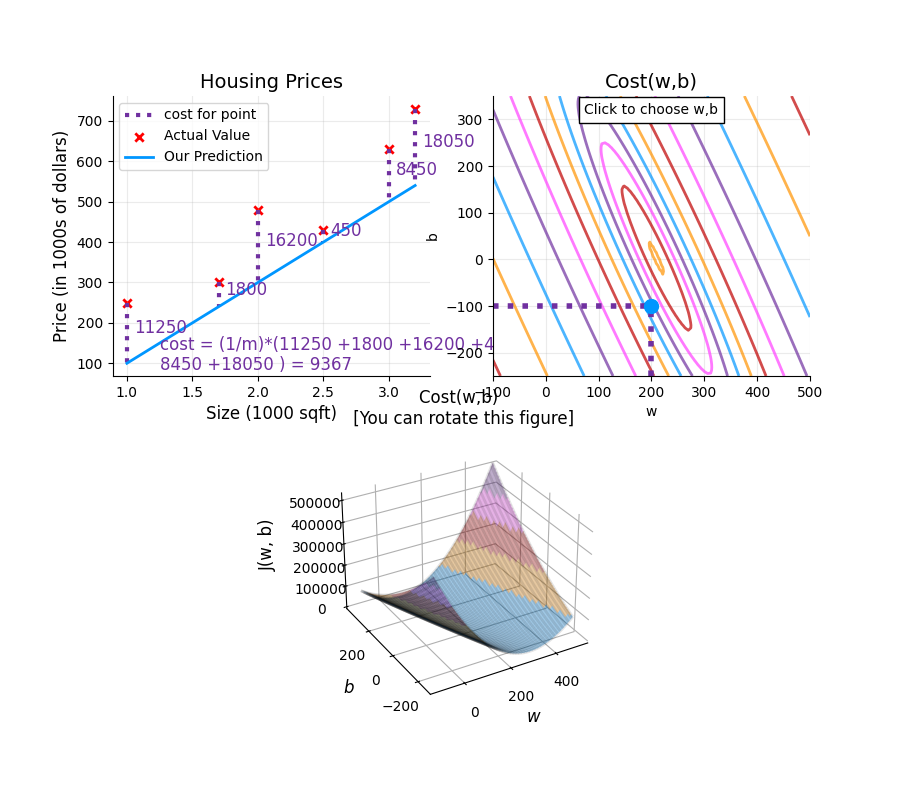

In [4]:
"""
6,使用更大的训练数据集
"""
x_train = np.array([1.0, 1.7, 2.0, 2.5, 3.0, 3.2]) # 创建新的输入数据
y_train = np.array([250, 300, 480, 430, 630, 730]) # 创建新的真实结果
print("x_train:", x_train) # 打印输入数据
print("y_train:", y_train) # 打印真实结果

"""
7,交互式观察 w,b 和成本函数
    plt_stationary: 创建图像
    plt_update_onclick: 让图像可以通过点击更新

    重点：
        点击不同位置
        观察 w,b 改变后
        预测线和 cost 如何变化
"""

plt.close('all') # 关闭之前打开的所有图像
fig, ax, dyn_items = plt_stationary(x_train, y_train) # 创建课程提供的交互式图像
updater = plt_update_onclick(fig, ax, x_train, y_train, dyn_items) # 创建点击更新功能

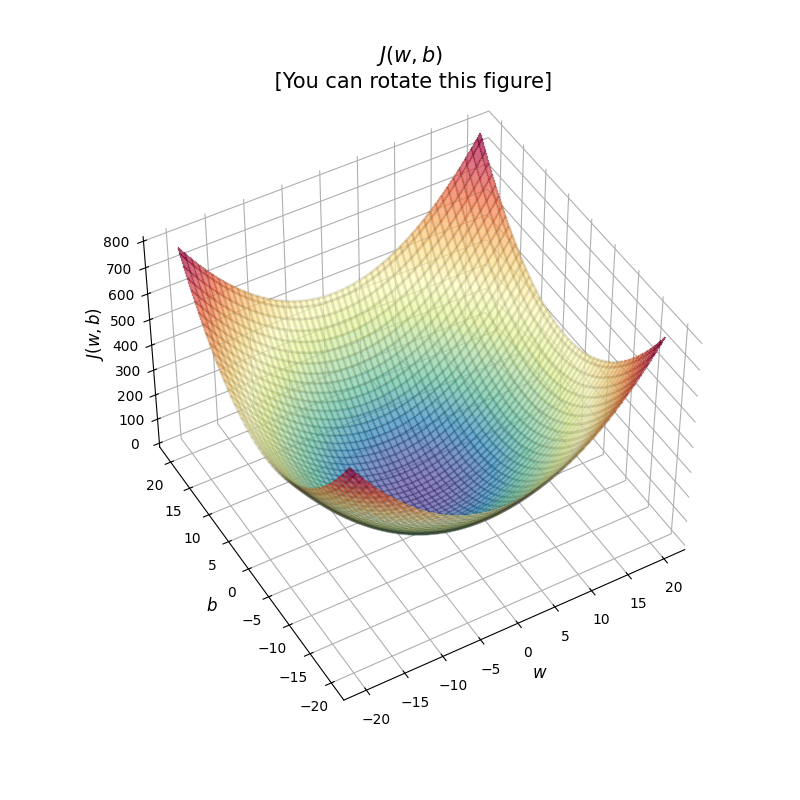

In [5]:
"""
8,三维可视化成本函数 soup_bowl
    作用： 展示 J(w,b) 的三维碗形图

    重点：
        碗底就是 J(w,b) 最小的位置
        碗底对应的 w,b 就是最优参数
"""
soup_bowl() # 调用课程提供的 3D 碗形成本函数图